In [1]:
# ==========================================
# Fake News Detection using NLP
# Phase 2 - Exploratory Data Analysis (EDA)
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

plt.style.use("ggplot")

In [2]:
news = pd.read_csv("../dataset/processed/news.csv")

print("="*60)
print("Processed Dataset")
print("="*60)

print(news.head())

print()

print("Shape :", news.shape)

Processed Dataset
                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   
3   OOPS: Trump Just Accidentally Confirmed He Le...   
4  Donald Trump heads for Scotland to reopen a go...   

                                                text       subject  \
0  21st Century Wire says Ben Stein, reputable pr...       US_News   
1  WASHINGTON (Reuters) - U.S. President Donald T...  politicsNews   
2  (Reuters) - Puerto Rico Governor Ricardo Rosse...  politicsNews   
3  On Monday, Donald Trump once again embarrassed...          News   
4  GLASGOW, Scotland (Reuters) - Most U.S. presid...  politicsNews   

                  date  label  
0    February 13, 2017      0  
1       April 5, 2017       1  
2  September 27, 2017       1  
3         May 22, 2017      0  
4       June 24, 2016       1  

Shape : (44898, 5)


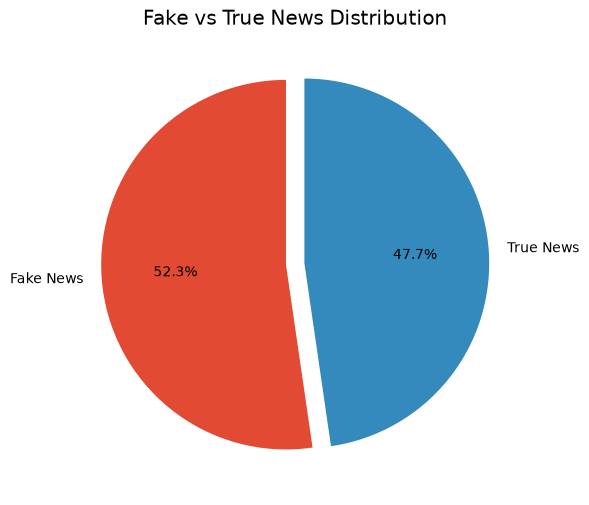

In [3]:
label_count = news["label"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    label_count,
    labels=["Fake News","True News"],
    autopct="%1.1f%%",
    startangle=90,
    explode=(0.05,0.05)
)

plt.title("Fake vs True News Distribution")

plt.show()

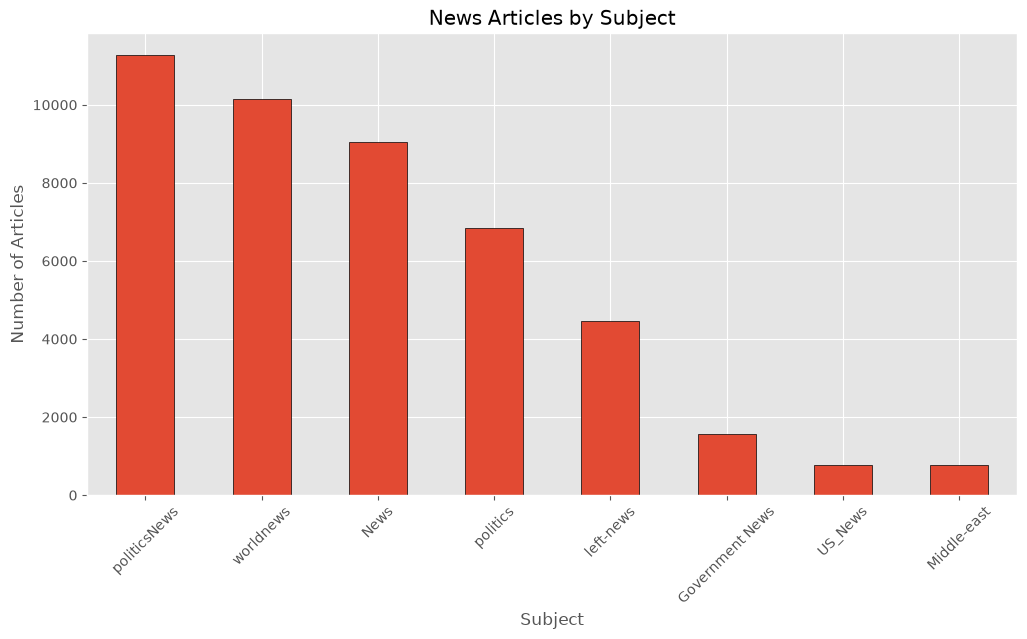

In [4]:
plt.figure(figsize=(12,6))

news["subject"].value_counts().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("News Articles by Subject")
plt.xlabel("Subject")
plt.ylabel("Number of Articles")

plt.xticks(rotation=45)

plt.show()

In [5]:
print("="*60)
print("Subject Distribution")
print("="*60)

print(news["subject"].value_counts())

Subject Distribution
subject
politicsNews       11272
worldnews          10145
News                9050
politics            6841
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64


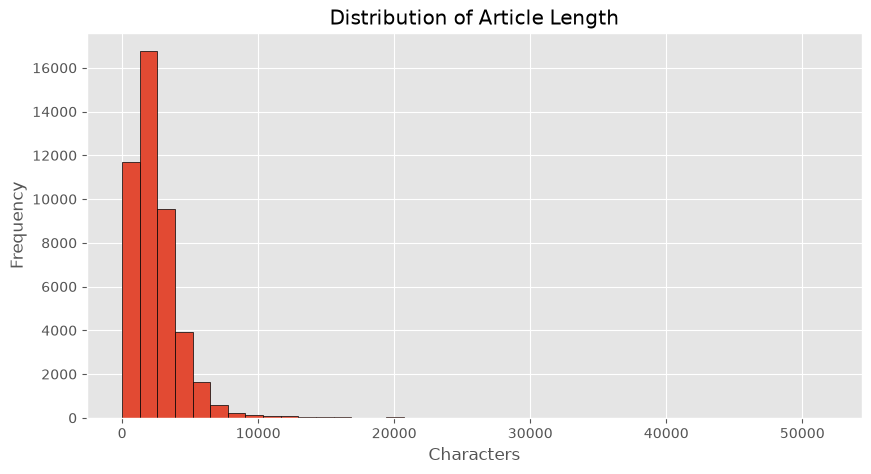

In [6]:
news["text_length"] = news["text"].apply(len)

plt.figure(figsize=(10,5))

plt.hist(
    news["text_length"],
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of Article Length")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

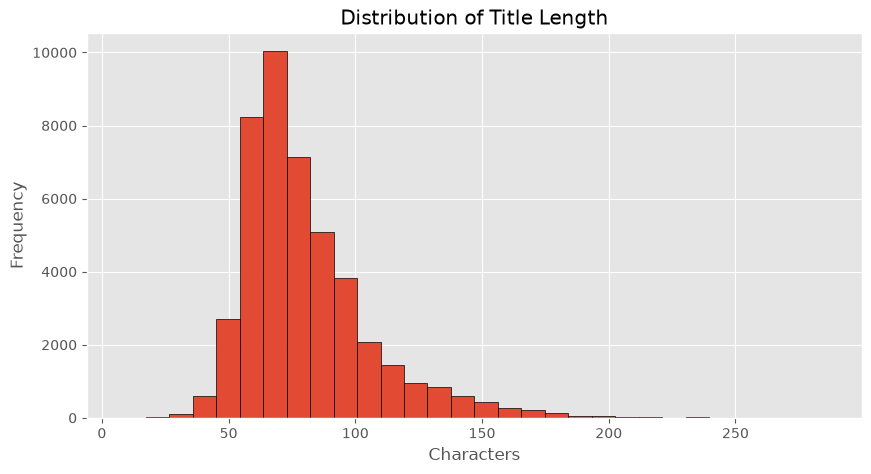

In [7]:
news["title_length"] = news["title"].apply(len)

plt.figure(figsize=(10,5))

plt.hist(
    news["title_length"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Title Length")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

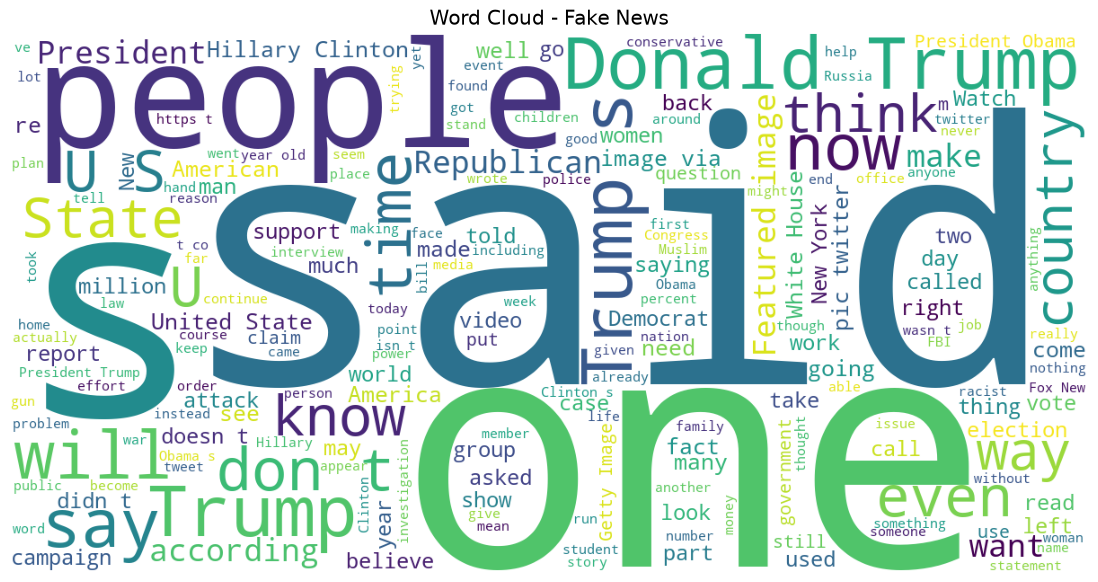

In [8]:
fake_text = " ".join(news[news["label"]==0]["text"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(fake_text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Word Cloud - Fake News")

plt.show()

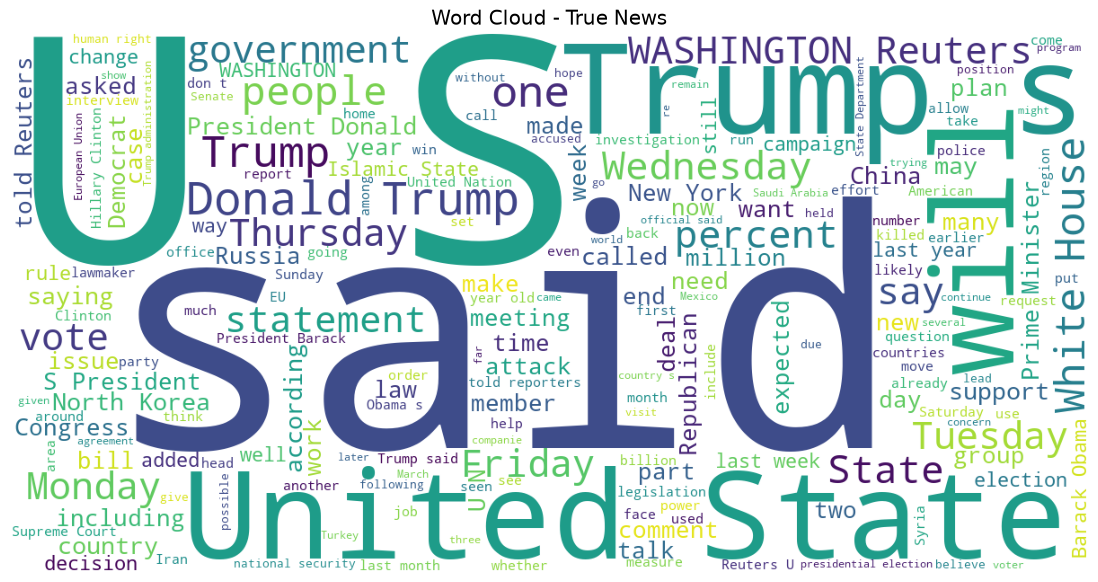

In [9]:
true_text = " ".join(news[news["label"]==1]["text"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(true_text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Word Cloud - True News")

plt.show()

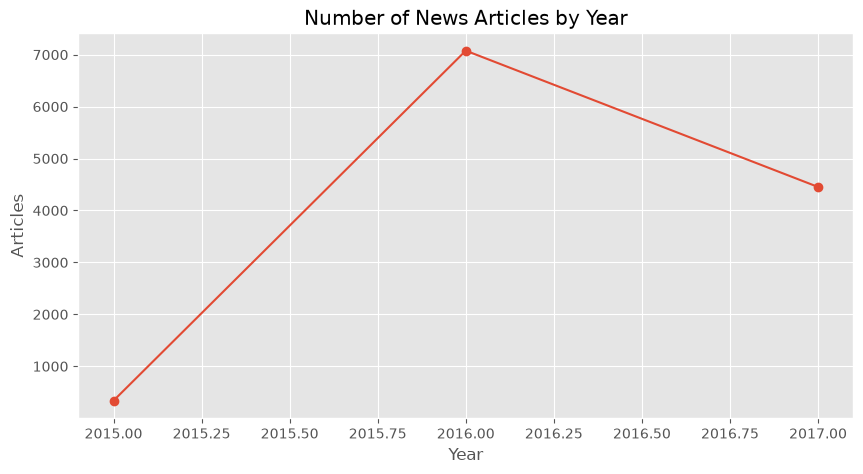

In [10]:
news["date"] = pd.to_datetime(news["date"], errors="coerce")

news["year"] = news["date"].dt.year

plt.figure(figsize=(10,5))

news["year"].value_counts().sort_index().plot(
    kind="line",
    marker="o"
)

plt.title("Number of News Articles by Year")

plt.xlabel("Year")

plt.ylabel("Articles")

plt.grid(True)

plt.show()

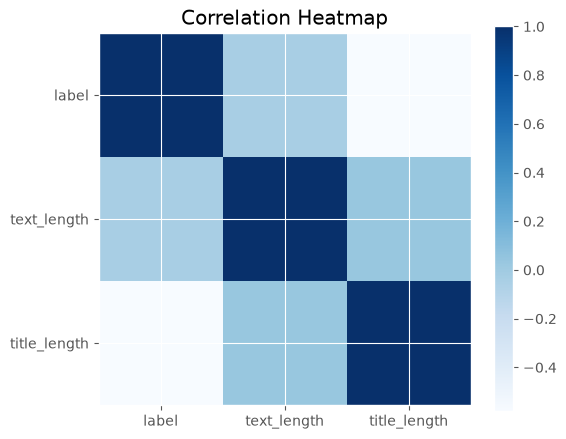

In [11]:
numeric = news[["label","text_length","title_length"]]

plt.figure(figsize=(6,5))

plt.imshow(numeric.corr(), cmap="Blues")

plt.xticks(range(3), numeric.columns)

plt.yticks(range(3), numeric.columns)

plt.colorbar()

plt.title("Correlation Heatmap")

plt.show()

In [12]:
print("="*60)
print("Exploratory Data Analysis Observations")
print("="*60)

print("1. The dataset contains both Fake and True news articles in balanced proportions.")
print("2. Politics-related news dominates the dataset.")
print("3. Article lengths vary significantly, indicating diversity in reporting style.")
print("4. Fake and True news use different sets of frequently occurring words.")
print("5. Publication dates span multiple years, enabling temporal analysis.")
print("6. The processed dataset is suitable for NLP preprocessing and machine learning.")
print("7. These insights provide a strong foundation for feature extraction and model development.")

print("\nEDA Completed Successfully.")

Exploratory Data Analysis Observations
1. The dataset contains both Fake and True news articles in balanced proportions.
2. Politics-related news dominates the dataset.
3. Article lengths vary significantly, indicating diversity in reporting style.
4. Fake and True news use different sets of frequently occurring words.
5. Publication dates span multiple years, enabling temporal analysis.
6. The processed dataset is suitable for NLP preprocessing and machine learning.
7. These insights provide a strong foundation for feature extraction and model development.

EDA Completed Successfully.
